# Lab 4: Data Visualization and EDA

#### CPE232 Data Models

---

1. Load all Superstore datasets.

*Note: The same datasets used in Lab 3*

In [36]:
# Write your code here
import pandas as pd

superstore_order = pd.read_csv('Superstore/superstore_order.csv')
superstore_people = pd.read_csv('Superstore/superstore_people.csv')
superstore_return = pd.read_csv('Superstore/superstore_return.csv')

2. Determine shape of each dataset (print out the results as well).

In [37]:
# Write your code here
print(f"Order: {superstore_order.shape}" )
print(f"People: {superstore_people.shape}" )
print(f"Return: {superstore_return.shape}")

Order: (8880, 21)
People: (4, 2)
Return: (296, 2)


3. Show information of the dataset.


In [38]:
# Write your code here
print(superstore_order.info())

<class 'pandas.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         8880 non-null   int64  
 1   Order ID       8880 non-null   str    
 2   Order Date     8880 non-null   str    
 3   Ship Date      8880 non-null   str    
 4   Ship Mode      8880 non-null   str    
 5   Customer ID    8880 non-null   str    
 6   Customer Name  8880 non-null   str    
 7   Segment        8880 non-null   str    
 8   Country        8880 non-null   str    
 9   City           8880 non-null   str    
 10  State          8880 non-null   str    
 11  Postal Code    8880 non-null   int64  
 12  Region         8880 non-null   str    
 13  Product ID     8880 non-null   str    
 14  Category       8880 non-null   str    
 15  Sub-Category   8880 non-null   str    
 16  Product Name   8880 non-null   str    
 17  Sales          8880 non-null   float64
 18  Quantity       8880

In [39]:
print(superstore_people.info())

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Person  4 non-null      str  
 1   Region  4 non-null      str  
dtypes: str(2)
memory usage: 196.0 bytes
None


In [40]:
print(superstore_return.info())

<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Returned  296 non-null    str  
 1   Order ID  296 non-null    str  
dtypes: str(2)
memory usage: 4.8 KB
None


4. Are there any missing values? If so, in which column?

Ans: No, there aren't.

In [41]:
print(superstore_order.isnull().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [42]:
print(superstore_people.isnull().sum())

Person    0
Region    0
dtype: int64


In [43]:
print(superstore_return.isnull().sum())

Returned    0
Order ID    0
dtype: int64


5.
- 5.1 List unique segments
- 5.2 List unique segments and their corresponding count
- 5.3 Create a pie chart to demonstrate unique segments and their count
- 5.4 Briefly describe what could be interpreted from this pie chart

*Note: please create additional cells to answer 5.2 - 5.3*

In [44]:
# Write your code here (5.1)
unique_seg = superstore_order['Segment'].unique()
print(unique_seg)

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [ ]:
#5.2
seg_counts = superstore_order['Segment'].value_counts()
print(seg_counts)

Segment
Consumer       4613
Corporate      2673
Home Office    1594
Name: count, dtype: int64


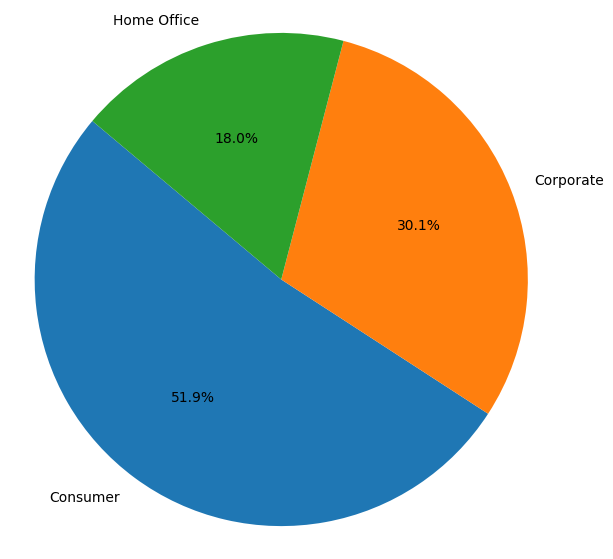

In [ ]:
#5.3
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7)) 
plt.pie(
    seg_counts, 
    labels=seg_counts.index, 
    autopct='%1.1f%%',
    startangle=140,   
)


plt.axis('equal') 
plt.show()

Answer for the question 5.4

Ans: From pie chart, this business has highly focus on Consumer,accounting for 51.9% of the total and the Corporate segment makes up the second-largest portion at 30.1%, while the Home Office segment accounts for the remaining 18.0%.

6.
- 6.1 List unique states
- 6.2 List top-10 unique states and their corresponding count
- 6.3 Create a bar chart (vertical) to demonstrate the count of top-10 unique states
- 6.4 Based on 6.2, also include the total sales of these states (show your result as a dataframe)
- 6.5 Using the result from 6.4, if you were the owner of this superstore, what information could be interpreted from this result?

*Note: please create additional cells to answer 6.2 - 6.4*

In [47]:
# Write your code here (6.1)
unique_states = superstore_order['State'].unique()
print(unique_states)

<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',            'Louisiana',          'Connecticut',
           'New Jersey',        'Massachusetts',              'Georgia',
               'Nevada',         'Rhode Island',          'Mississippi',
             'Arkansas',              'Montana',        'New Hampshire',
             'Maryland', 'District of

In [ ]:
#6.2
state_top10 = superstore_order['State'].value_counts().nlargest(10)
state_top10


State
California        1754
New York          1001
Texas              860
Pennsylvania       531
Washington         452
Illinois           427
Ohio               396
Florida            339
Michigan           230
North Carolina     229
Name: count, dtype: int64

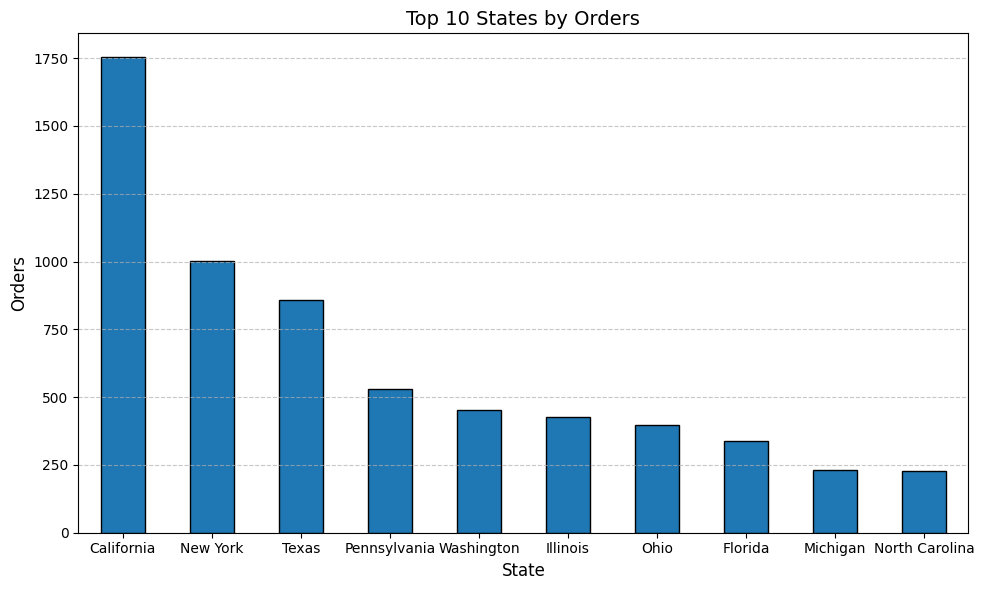

In [ ]:
#6.3
plt.figure(figsize=(10, 6))
state_top10.plot(kind='bar', edgecolor='black')
plt.title('Top 10 States by Orders', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Orders', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

In [ ]:
#6.4
states_top10_list = superstore_order['State'].value_counts().nlargest(10).index.tolist()
top10df = superstore_order[superstore_order['State'].isin(states_top10_list)]
top10_sale = top10df.groupby('State').agg(
    Order=('State', 'count'),
    Total_Sales=('Sales', 'sum')
)
top10_sale = top10_sale.sort_values(by='Order', ascending=False)
print(top10_sale)

                Order  Total_Sales
State                             
California       1754  399195.4555
New York         1001  274866.8190
Texas             860  147855.0282
Pennsylvania      531  103852.5210
Washington        452  124497.7780
Illinois          427   71456.1780
Ohio              396   67924.2140
Florida           339   84083.0880
Michigan          230   62147.6960
North Carolina    229   49962.1580


Answer for the question 6.5

Ans: From the table, this supermarket has mainly sales in California, New York and Texas by comparing the other top 10 sales that have equal or less than 600 order.

7.
- 7.1 List unique categories
- 7.2 Create a bar chart (horizontal) to demonstrate the proportion of these categories
- 7.3 Compute the ratio of these categories in percentage and print the results

*Note: please create additional cells to answer 7.2 - 7.3*

In [50]:
# Write your code here (7.1)
unique_category = superstore_order['Category'].unique()
print(unique_category)

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str


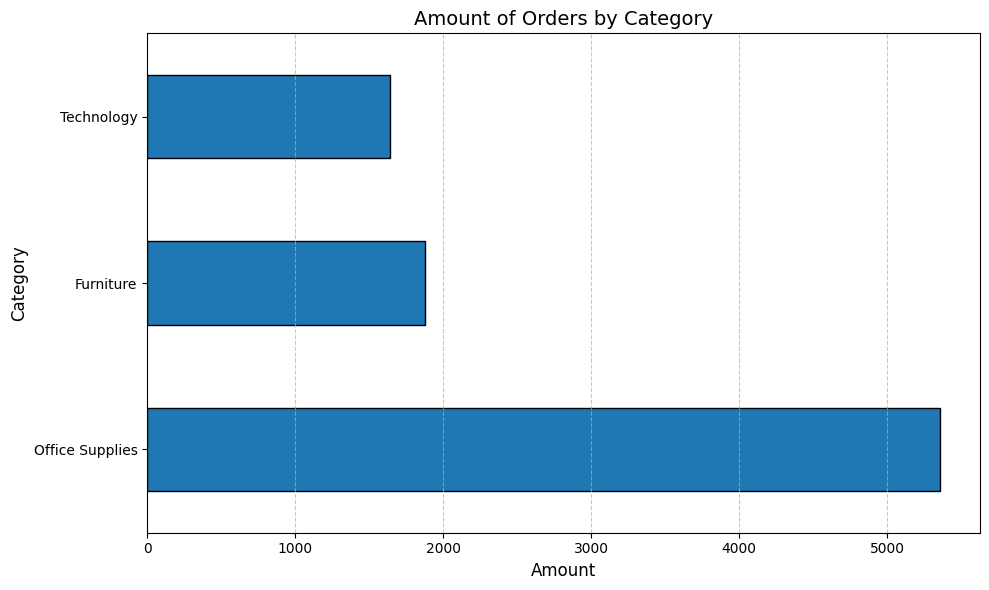

In [ ]:
#7.2
category_count = superstore_order['Category'].value_counts()
plt.figure(figsize=(10, 6))
category_count.plot(kind='barh', edgecolor='black')
plt.title('Amount of Orders by Category', fontsize=14)
plt.xlabel('Amount', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

In [ ]:
#7.3
category_percentages = superstore_order['Category'].value_counts(normalize=True) * 100
print("Percentage of Orders by Category:")
print(category_percentages)


Percentage of Orders by Category:
Category
Office Supplies    60.360360
Furniture          21.171171
Technology         18.468468
Name: proportion, dtype: float64


8. Update the type of all columns that contain dates to *datetime* and show information after an update.

In [53]:
# write your code here

superstore_order['Order Date'] = pd.to_datetime(superstore_order['Order Date'], format='%d/%m/%Y')
superstore_order['Ship Date'] = pd.to_datetime(superstore_order['Ship Date'], format='%d/%m/%Y')
superstore_order.info()

<class 'pandas.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         8880 non-null   int64         
 1   Order ID       8880 non-null   str           
 2   Order Date     8880 non-null   datetime64[us]
 3   Ship Date      8880 non-null   datetime64[us]
 4   Ship Mode      8880 non-null   str           
 5   Customer ID    8880 non-null   str           
 6   Customer Name  8880 non-null   str           
 7   Segment        8880 non-null   str           
 8   Country        8880 non-null   str           
 9   City           8880 non-null   str           
 10  State          8880 non-null   str           
 11  Postal Code    8880 non-null   int64         
 12  Region         8880 non-null   str           
 13  Product ID     8880 non-null   str           
 14  Category       8880 non-null   str           
 15  Sub-Category   8880 non-null   s

9. Create a new column "Processing time day" to show number of days taken to ship an order and show your result in a dataframe format.

*Hint: The duration starts as soon as the item has been ordered and ends once the order has successfully shipped.*

In [54]:
# write your code here
superstore_order['Processing time day'] = (superstore_order['Ship Date'] - superstore_order['Order Date']).dt.days

print(superstore_order[['Order Date', 'Ship Date', 'Processing time day']].head())

  Order Date  Ship Date  Processing time day
0 2016-11-08 2016-11-11                    3
1 2016-11-08 2016-11-11                    3
2 2016-06-12 2016-06-16                    4
3 2015-10-11 2015-10-18                    7
4 2015-10-11 2015-10-18                    7


10. Based on the result in 9.
- 10.1 How many orders are there that take more than 5 days to process?
- 10.2 Show the top 5 rows (expected output should contain these columns: Order ID, Order Date, Ship Date, Processing time day, Quantity)
- 10.3 Plot the histogram based on the column Quantity

*Note: please create additional cells to answer 10.2 - 10.3*

In [55]:
# Write your code here (10.1)
ordermorethan5 = superstore_order[superstore_order['Processing time day'] > 5]
print(len(ordermorethan5))

1656


In [ ]:
#10.2
ordermorethan5 = ordermorethan5.sort_values(by='Processing time day', ascending=False)
print(ordermorethan5[['Order ID', 'Order Date', 'Ship Date', 'Processing time day', 'Quantity']].head())

            Order ID Order Date  Ship Date  Processing time day  Quantity
86    CA-2017-155558 2017-10-26 2017-11-02                    7         1
87    CA-2017-155558 2017-10-26 2017-11-02                    7         2
3     US-2015-108966 2015-10-11 2015-10-18                    7         5
8860  CA-2015-125934 2015-09-11 2015-09-18                    7         3
8861  CA-2015-125934 2015-09-11 2015-09-18                    7         4


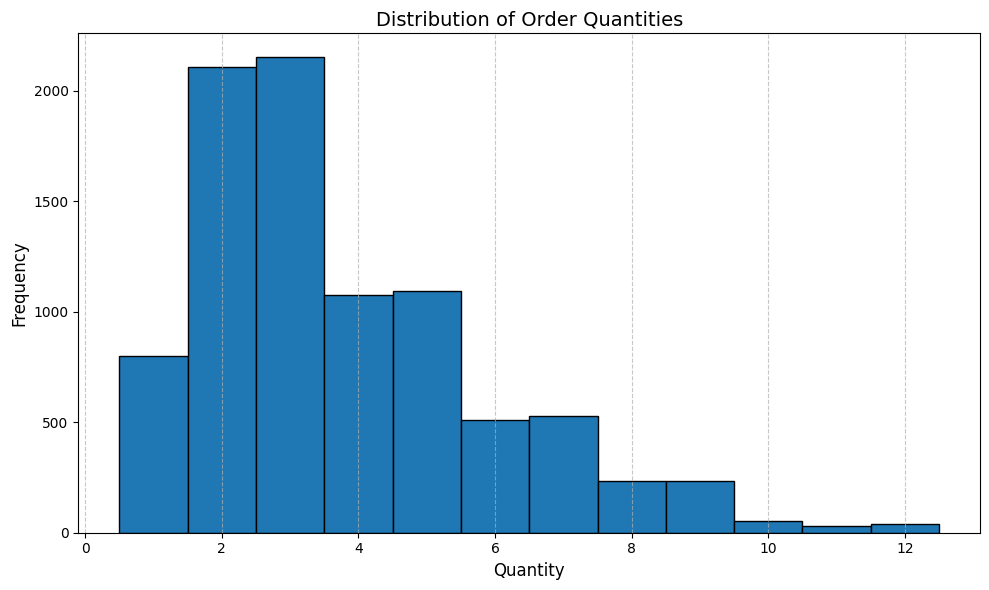

In [ ]:
#10.3
plt.figure(figsize=(10, 6))
plt.hist(superstore_order['Quantity'], 
         bins=range(1, superstore_order['Quantity'].max()), 
         edgecolor='black',
         align='left')
plt.title('Distribution of Order Quantities', fontsize=14)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

11. Total sales compare across different regions
  
- 11.1 Create a bar chart to visualize.

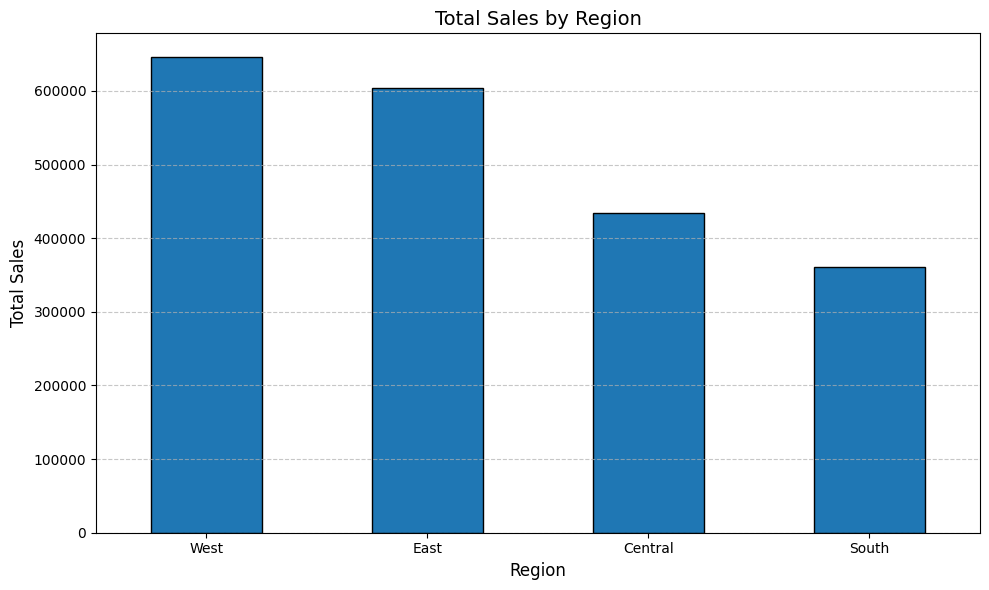

In [ ]:
# Write your code here (11.1)
salebyregion = superstore_order.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
salebyregion.plot(kind='bar', edgecolor='black')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

In [154]:
salebyregion 


Region
West       645943.7905
East       603648.0590
Central    434723.2222
South      361376.7910
Name: Sales, dtype: float64

- 11.2 How do total sales compare across different regions? Explain in as much detail as possible.
  
  Ans: From the chart, The main market regions are West and East. These two are the primary revenue for the company, significantly better than the other two. The Central region is in a distant third place, with sales hovering around 500,000. The South has the lowest performance of all, generating nearly half the revenue of the top region.

12.Which states have the highest number of returns? Use a horizontal bar chart.

Ans: California has highest nummber of returns which is 298 times.

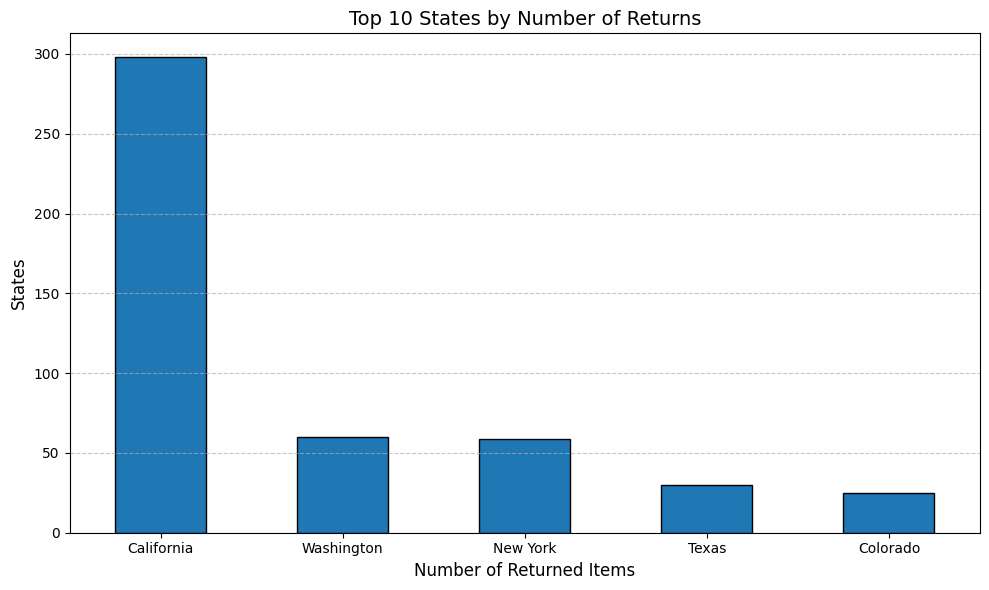

State
California    298
Washington     60
New York       59
Texas          30
Colorado       25
Name: count, dtype: int64


In [90]:
# Write your code here (12)
combined_orderreturn = pd.merge(superstore_order, superstore_return, on='Order ID', how='inner')
orderreturntop5= combined_orderreturn['State'].value_counts().nlargest(5)
plt.figure(figsize=(10, 6))
orderreturntop5.plot(kind='bar', edgecolor='black')
plt.title('Top 10 States by Number of Returns', fontsize=14)
plt.xlabel('Number of Returned Items', fontsize=12)
plt.ylabel('States', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()
print(orderreturntop5)

13. What is the correlation between numerical variables in the superstore_order dataset? Use a heatmap
*Hint: Use seaborn to create a heatmap :)*

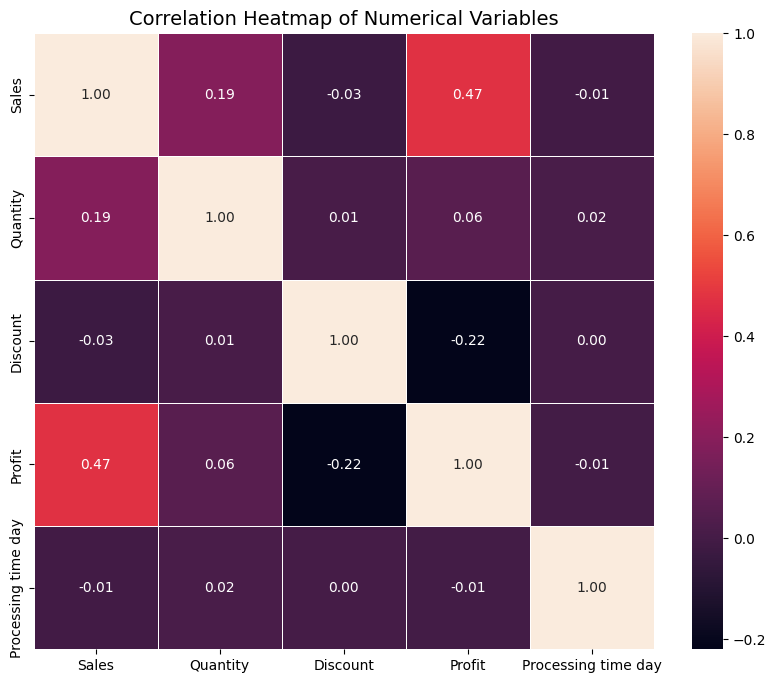

In [96]:
# Write your code here (13)
import seaborn as sns
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Processing time day']
corr_data = superstore_order[numerical_cols]
correlation_matrix = corr_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,          
            fmt=".2f",         
            linewidths=0.5,)   

plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)
plt.show()

14. Create a USA State-Level Choropleth Map to visualize total sales per state.

*   The darkest color represents the highest total sales.
*   The lightest color represents the lowest total sales.
*   Use a continuous gradient scale (e.g., dark blue to light blue, dark red to light red, or any custom gradient of your choice).

*Hint: Use plotly.express*

In [157]:
# Write your code here (14)
import plotly.express as px
state_sales = superstore_order.groupby('State')['Sales'].sum().reset_index()
state_codes  = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}
state_sales['Code'] = state_sales['State'].map(state_codes)
fig = px.choropleth(
    state_sales,
    locations='Code',           
    locationmode="USA-states", 
    color='Sales',            
    scope="usa",                
    color_continuous_scale="Oranges", 
    title='Total Sales by State (USA)',
)

fig.show()

  14.2 Answer the following questions:
1.   Which state has the highest total sales?
2.   How do sales anomalies affect the gradient color shading on the map?
3.   If you change the color scale, does it impact readability? Why or why not?

Ans:


1. California has highest total sales.
2. If a state has a huge outlier compared to others, the map becomes very hard to read.
3. Yes, it does because if you change the color to low contrast you will hard to see the different shades.



15. Create a box plot to compare the different shipping modes based on total profit.

<Figure size 1200x600 with 0 Axes>

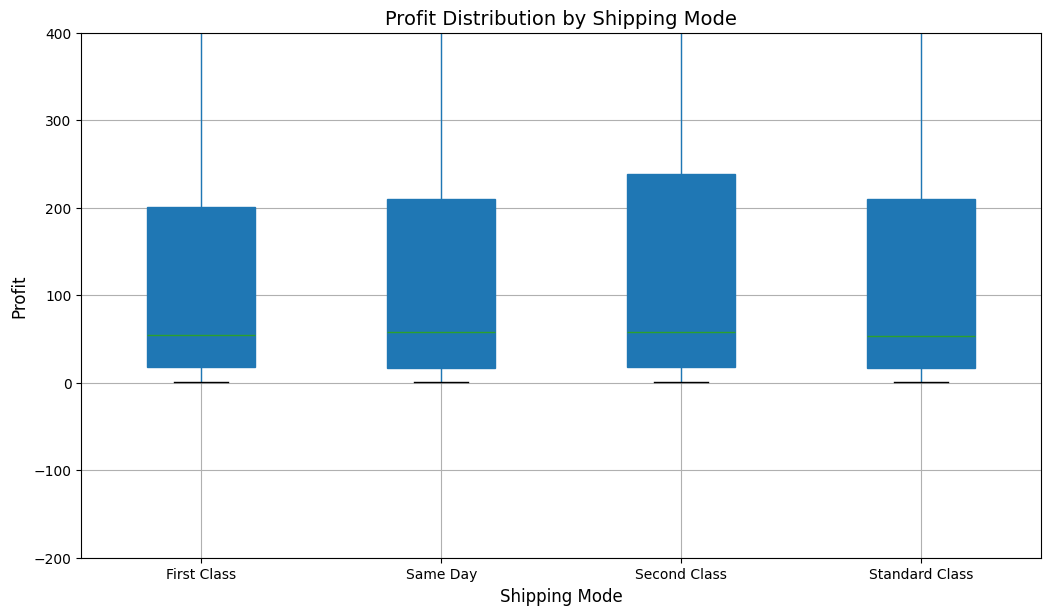

In [ ]:
#Write your code here (15)
plt.figure(figsize=(12, 6))
superstore_order.boxplot(column='Sales', by='Ship Mode', figsize=(12, 7), patch_artist=True)
plt.title('Profit Distribution by Shipping Mode', fontsize=14)
plt.suptitle('') 
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Profit', fontsize=12)

plt.ylim(-200, 400) 

plt.show()

15.2 Which shipping mode has the highest median profit?

Ans: Second Class has highest median profit which is 9.76 dollars

In [ ]:
median_profits = superstore_order.groupby('Ship Mode')['Profit'].median().sort_values(ascending=False)
print(median_profits)

Ship Mode
Second Class      9.76080
First Class       8.79255
Same Day          8.43490
Standard Class    8.31040
Name: Profit, dtype: float64


[BONUS 20 pts] Determine the percentage of customers who:
- B1)returned the product once
- B2) returned the product at least once
- B3) never returned the product
- Finally, Plot a comparison of B2 and B3

*Note: please create additional cells to answer the above points*

In [ ]:
# Write your code here
#B1
data = pd.merge(superstore_order, superstore_return, on='Order ID', how='inner')
return_counts = data.groupby('Customer ID')['Order ID'].nunique()
total_customers = superstore_order['Customer ID'].nunique()
b1_count = (return_counts == 1).sum()
b1_pct = (b1_count/total_customers)*100
print(f"B1: {b1_pct:.2f}% ({b1_count})")


B1: 23.57% (186)


In [ ]:
#B2
b2_count = return_counts.sum()
b2_pct = (b2_count/total_customers)*100
print(f"B2: {b2_pct:.2f}% ({b2_count})")

B2: 33.33% (263)


In [ ]:
#B3
b3_count = total_customers - b2_count
b3_pct = (b3_count/total_customers)*100
print(f"B3: {b3_pct:.2f}% ({b3_count})")

B3: 66.67% (526)


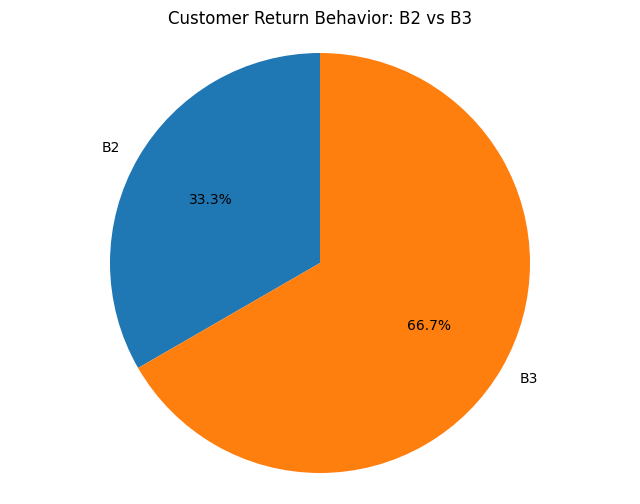

In [ ]:
#Plot a comparison of B2 and B3
labels = ['B2', 'B3']
values = [b2_count,b3_count]
plt.figure(figsize=(8, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Customer Return Behavior: B2 vs B3')
plt.axis('equal') 
plt.show()